# Proyecto Parcial 
## Automatización de análisis y visualización de datos climáticos

**Asignatura:** Bases de Programación

**Programa:** Maestría en Ciencias de la Tierra

**Grupo:** Kevin Loor, Carola Gordillo e Ingrid Orta

**Archivo de datos:** [`Weather_Data-1.csv`](https://espolec-my.sharepoint.com/:x:/g/personal/cgordill_espol_edu_ec/IQDIthk0ayHgSKgJRik1kSm7ARX9jTVIAwJcLwE_tAFaCrg?e=uY3cHd)

**Documento con instrucciones base:** [`Proyecto Primer Parcial_BasesdeProgramación.pdf`](https://espolec-my.sharepoint.com/:b:/g/personal/cgordill_espol_edu_ec/IQB4T_SPsphKRq9UyezR_kSKAS-qYN7bzGqdVDFru2nbPmg?e=rTsg9p)

**Repositorio GitHub:** https://github.com/kevinloorf95-glitch/proyectoBP.git


## I. Introducción

Los datos climáticos contienen información sobre temperatura, humedad, precipitación, velocidad del viento y sensación térmica registrada en diferentes ciudades y fechas. Su análisis permite comprender patrones ambientales, detectar valores atípicos y generar información útil para la toma de decisiones.

En este proyecto se desarrolló un flujo automatizado utilizando Python, Pandas y Matplotlib para importar, limpiar, analizar y visualizar los datos, garantizando un proceso reproducible y reutilizable.

## II. Objetivo del Proyecto

## Objetivo General
El objetivo del proyecto es automatizar el proceso de carga, limpieza, análisis y visualización de un conjunto de datos climáticos mediante el uso de bucles y funciones, para el aumento de la eficiencia y la reproducibilidad del análisis de la información.

## Objetivos específicos
- Cargar datos utilizando Pandas.
- Limpiar automáticamente el dataset.
- Crear funciones reutilizables.
- Automatizar el análisis estadístico.
- Generar gráficos automáticamente.

## III. Descripción del conjunto de datos (dataset)

## III.1. Preparación del entorno

Se utilizan bibliotecas comunes para análisis de datos:

- `pandas`: carga, limpieza, transformación y agrupación de datos.
- `numpy`: cálculos numéricos.
- `matplotlib`: visualización.
- `seaborn`: visualización estadística. Si no está instalada, el cuaderno usa alternativas con `matplotlib`.
- `pathlib`: manejo ordenado de rutas.

El diseño del código prioriza funciones reutilizables para que cada etapa del análisis pueda ejecutarse nuevamente con pocos cambios.

In [1]:
from pathlib import Path
import importlib.util
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEABORN_DISPONIBLE = importlib.util.find_spec("seaborn") is not None

if SEABORN_DISPONIBLE:
    import seaborn as sns
else:
    sns = None

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "Weather_Data-1.csv"
OUTPUT_DIR = BASE_DIR / "salidas"
FIG_DIR = OUTPUT_DIR / "graficos"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Archivo de datos: {DATA_PATH}")
print(f"Seaborn disponible: {SEABORN_DISPONIBLE}")

Archivo de datos: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\Weather_Data-1.csv
Seaborn disponible: False


El archivo `Weather_Data-1.csv` contiene observaciones climáticas por ciudad y fecha. De acuerdo con la inspección inicial realizada sobre el archivo, el conjunto tiene:

- **1,000,000 registros**.
- **6 columnas originales**.
- **10 ciudades**.
- Periodo observado: **2024-01-01 00:00:00** a **2024-05-18 19:44:00**.

### Variables originales

| Variable | Descripción |
|---|---|
| `Location` | Ciudad donde se registró la observación. |
| `Date_Time` | Fecha y hora de la observación. |
| `Temperature_C` | Temperatura en grados Celsius. |
| `Humidity_pct` | Humedad relativa en porcentaje. |
| `Precipitation_mm` | Precipitación en milímetros. |
| `Wind_Speed_kmh` | Velocidad del viento en km/h. |

Estas variables permiten analizar patrones generales de temperatura, humedad, precipitación y viento por ciudad y por periodo.

In [2]:
def cargar_datos(ruta_archivo):
    '''Carga el archivo CSV y devuelve un DataFrame.'''
    return pd.read_csv(ruta_archivo)


df_original = cargar_datos(DATA_PATH)
df_original.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,1/14/2024 21:12,10.683001,41.195754,4.020119,8.233540
1,San Diego,5/17/2024 15:22,8.734140,58.319107,9.111623,27.715161
2,San Diego,5/11/2024 9:30,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2/26/2024 17:32,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,4/29/2024 13:23,39.808213,72.899908,9.598282,29.898622


In [3]:
print("Dimensiones del DataFrame original:", df_original.shape)
print("\nTipos de datos originales:")
display(df_original.dtypes)

print("\nCantidad de ciudades:")
display(df_original["Location"].nunique())

print("\nFrecuencia por ciudad:")
display(df_original["Location"].value_counts())

Dimensiones del DataFrame original: (1000000, 6)

Tipos de datos originales:


Location                str
Date_Time               str
Temperature_C       float64
Humidity_pct        float64
Precipitation_mm    float64
Wind_Speed_kmh      float64
dtype: object


Cantidad de ciudades:


10


Frecuencia por ciudad:


Location
Phoenix         100209
Chicago         100164
Philadelphia    100122
Houston         100076
New York         99972
San Antonio      99962
Dallas           99936
Los Angeles      99922
San Jose         99863
San Diego        99774
Name: count, dtype: int64

## III.2. Funciones de limpieza y preparación

La limpieza básica se organiza en funciones independientes. Esto permite probar cada paso y reutilizarlo si se recibe un archivo nuevo con el mismo formato.

Las acciones principales son:

- Convertir `Date_Time` a tipo fecha.
- Eliminar duplicados.
- Eliminar registros con fechas inválidas.
- Convertir variables numéricas.
- Crear variables temporales (`Year`, `Month`, `Month_Name`, `Day`, `Hour`).
- Crear variables derivadas para apoyar el análisis.

In [4]:
def convertir_fecha(df, columna_fecha="Date_Time"):
    '''Convierte una columna de texto a fecha; valores inválidos pasan a NaT.'''
    datos = df.copy()
    datos[columna_fecha] = pd.to_datetime(datos[columna_fecha], errors="coerce")
    return datos


def convertir_numericas(df, columnas):
    '''Convierte columnas a numérico y fuerza valores inválidos a NaN.'''
    datos = df.copy()
    for columna in columnas:
        datos[columna] = pd.to_numeric(datos[columna], errors="coerce")
    return datos


def eliminar_duplicados(df):
    '''Elimina filas duplicadas completas.'''
    return df.drop_duplicates().copy()


def eliminar_filas_invalidas(df, columnas_requeridas):
    '''Elimina registros con nulos en columnas necesarias para el análisis.'''
    return df.dropna(subset=columnas_requeridas).copy()


def agregar_variables_temporales(df, columna_fecha="Date_Time"):
    '''Agrega año, mes, nombre del mes, día y hora.'''
    datos = df.copy()
    datos["Year"] = datos[columna_fecha].dt.year
    datos["Month"] = datos[columna_fecha].dt.month
    datos["Month_Name"] = datos[columna_fecha].dt.month_name()
    datos["Day"] = datos[columna_fecha].dt.day
    datos["Hour"] = datos[columna_fecha].dt.hour
    return datos


def calcular_sensacion_termica(df):
    '''
    Calcula una aproximación de sensación térmica en Celsius.

    Fórmula aproximada:
    ST = T + 0.33*e - 0.70*V - 4
    donde e depende de temperatura y humedad relativa, y V es viento en m/s.
    '''
    datos = df.copy()
    temperatura = datos["Temperature_C"]
    humedad = datos["Humidity_pct"]
    viento_ms = datos["Wind_Speed_kmh"] / 3.6
    presion_vapor = (humedad / 100) * 6.105 * np.exp((17.27 * temperatura) / (237.7 + temperatura))
    datos["Thermal_Sensation_C"] = temperatura + (0.33 * presion_vapor) - (0.70 * viento_ms) - 4
    return datos


def clasificar_temperatura(valor):
    '''Clasifica la temperatura para facilitar interpretaciones categóricas.'''
    if valor < 0:
        return "Muy fria"
    if valor < 10:
        return "Fria"
    if valor < 25:
        return "Templada"
    if valor < 35:
        return "Calida"
    return "Muy calida"


def agregar_columnas_derivadas(df):
    '''Crea columnas derivadas de las variables originales.'''
    datos = calcular_sensacion_termica(df)
    datos["Temperature_Category"] = datos["Temperature_C"].apply(clasificar_temperatura)
    datos["Rain_Event"] = datos["Precipitation_mm"] > 0
    datos["Wind_Level"] = pd.cut(
        datos["Wind_Speed_kmh"],
        bins=[-np.inf, 10, 20, np.inf],
        labels=["Bajo", "Moderado", "Alto"]
    )
    return datos


def limpiar_preparar_datos(df):
    '''Ejecuta el flujo completo de limpieza y preparación.'''
    columnas_numericas = ["Temperature_C", "Humidity_pct", "Precipitation_mm", "Wind_Speed_kmh"]
    columnas_requeridas = ["Location", "Date_Time"] + columnas_numericas

    datos = convertir_fecha(df)
    datos = convertir_numericas(datos, columnas_numericas)
    datos = eliminar_duplicados(datos)
    datos = eliminar_filas_invalidas(datos, columnas_requeridas)
    datos = agregar_variables_temporales(datos)
    datos = agregar_columnas_derivadas(datos)
    return datos


df = limpiar_preparar_datos(df_original)
df.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Year,Month,Month_Name,Day,Hour,Thermal_Sensation_C,Temperature_Category,Rain_Event,Wind_Level
0,San Diego,2024-01-14 21:12:00,10.683001,41.195754,4.020119,8.233540,2024,1,January,14,21,6.826410,Templada,True,Bajo
1,San Diego,2024-05-17 15:22:00,8.734140,58.319107,9.111623,27.715161,2024,5,May,17,15,1.511964,Fria,True,Alto
2,San Diego,2024-05-11 09:30:00,11.632436,38.820175,4.607511,28.732951,2024,5,May,11,9,3.796033,Templada,True,Alto
3,Philadelphia,2024-02-26 17:32:00,-8.628976,54.074474,3.183720,26.367303,2024,2,February,26,17,-17.187542,Muy fria,True,Alto
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,9.598282,29.898622,2024,4,April,29,13,47.486231,Muy calida,True,Alto


## III.3 Resumen estadístico de los datos

In [5]:
def reporte_calidad(df_antes, df_despues):
    '''Genera un resumen de calidad antes y después de la limpieza.'''
    resumen = pd.DataFrame({
        "Metrica": [
            "Filas originales",
            "Filas finales",
            "Columnas originales",
            "Columnas finales",
            "Duplicados originales",
            "Duplicados finales",
            "Valores nulos finales"
        ],
        "Valor": [
            len(df_antes),
            len(df_despues),
            df_antes.shape[1],
            df_despues.shape[1],
            df_antes.duplicated().sum(),
            df_despues.duplicated().sum(),
            int(df_despues.isna().sum().sum())
        ]
    })
    return resumen


display(reporte_calidad(df_original, df))
display(df.isna().sum().to_frame("Nulos"))

df.describe()
df.info()

,Metrica,Valor
0,Filas originales,1000000
1,Filas finales,1000000
2,Columnas originales,6
3,Columnas finales,15
4,Duplicados originales,0
5,Duplicados finales,0
6,Valores nulos finales,0


,Nulos
Location,0
Date_Time,0
Temperature_C,0
Humidity_pct,0
Precipitation_mm,0
Wind_Speed_kmh,0
Year,0
Month,0
Month_Name,0
Day,0


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Location              1000000 non-null  str           
 1   Date_Time             1000000 non-null  datetime64[us]
 2   Temperature_C         1000000 non-null  float64       
 3   Humidity_pct          1000000 non-null  float64       
 4   Precipitation_mm      1000000 non-null  float64       
 5   Wind_Speed_kmh        1000000 non-null  float64       
 6   Year                  1000000 non-null  int32         
 7   Month                 1000000 non-null  int32         
 8   Month_Name            1000000 non-null  str           
 9   Day                   1000000 non-null  int32         
 10  Hour                  1000000 non-null  int32         
 11  Thermal_Sensation_C   1000000 non-null  float64       
 12  Temperature_Category  1000000 non-null  str           

## IV. Análisis exploratorio de datos y manipulación de Datos con Pandas


El análisis exploratorio busca responder:

- ¿Cuáles son los valores centrales y la dispersión de cada variable climática?
- ¿Qué ciudades presentan mayores promedios de temperatura, precipitación o viento?
- ¿Qué mes tiene la temperatura promedio más alta?
- ¿Existe relación lineal fuerte entre las variables numéricas?

Para automatizar el EDA se usan listas de columnas, diccionarios de resultados, bucles y funciones.

## IV.1 Estructuras de datos para almacenar y manipular información relevante

In [6]:
columnas_climaticas = ["Temperature_C", "Humidity_pct", "Precipitation_mm", "Wind_Speed_kmh", "Thermal_Sensation_C"]

units = {"Temperature_C":"ºC", "Humidity_pct":"%", "Precipitation_mm":"mm", "Wind_Speed_kmh":"km/h", "Thermal_Sensation_C":"ºC"}

## IV.2 Estadísticas descriptivas

In [7]:
def estadisticas_descriptivas(df, columnas):
    '''Calcula media, mediana, desviación estándar, mínimo y máximo para varias columnas.'''
    resultados = []
    for columna in columnas:
        resultados.append({
            "Variable": columna,
            "Unit": units.get(columna,"N/A"),
            "Media": df[columna].mean(),
            "Mediana": df[columna].median(),
            "Desviacion_estandar": df[columna].std(),
            "Minimo": df[columna].min(),
            "Maximo": df[columna].max()
        })
    return pd.DataFrame(resultados).round(3)


resumen_estadistico = estadisticas_descriptivas(df, columnas_climaticas)
display(resumen_estadistico)

,Variable,Unit,Media,Mediana,Desviacion_estandar,Minimo,Maximo
0,Temperature_C,ºC,14.780,14.778,14.483,-19.969,40.000
1,Humidity_pct,%,60.022,60.019,17.324,30.000,90.000
2,Precipitation_mm,mm,5.110,5.110,2.948,0.000,14.972
3,Wind_Speed_kmh,km/h,14.998,14.994,8.664,0.000,30.000
4,Thermal_Sensation_C,ºC,12.526,11.151,18.326,-28.701,57.550


In [8]:
display(df[columnas_climaticas].describe().round(3))

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Thermal_Sensation_C
count,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000
mean,14.780,60.022,5.110,14.998,12.526
std,14.483,17.324,2.948,8.664,18.326
min,-19.969,30.000,0.000,0.000,-28.701
25%,2.270,45.008,2.581,7.490,-3.223
50%,14.778,60.019,5.110,14.994,11.151
75%,27.270,75.044,7.614,22.514,27.360
max,40.000,90.000,14.972,30.000,57.550


## IV.3 Análisis específicos al conjunto de datos

In [9]:
def agrupar_por_ciudad(df):
    '''Calcula indicadores promedio y extremos por ciudad.'''
    return (
        df.groupby("Location")
        .agg(
            registros=("Location", "size"),
            temp_media=("Temperature_C", "mean"),
            temp_maxima=("Temperature_C", "max"),
            temp_minima=("Temperature_C", "min"),
            humedad_media=("Humidity_pct", "mean"),
            precipitacion_total=("Precipitation_mm", "sum"),
            precipitacion_media=("Precipitation_mm", "mean"),
            viento_medio=("Wind_Speed_kmh", "mean"),
            viento_maximo=("Wind_Speed_kmh", "max"),
            sensacion_media=("Thermal_Sensation_C", "mean")
        )
        .sort_values("temp_media", ascending=False)
        .round(3)
    )


resumen_ciudad = agrupar_por_ciudad(df)
display(resumen_ciudad)

,registros,temp_media,temp_maxima,temp_minima,humedad_media,precipitacion_total,precipitacion_media,viento_medio,viento_maximo,sensacion_media
Location,,,,,,,,,,
Los Angeles,99922,15.081,40.000,-10.000,60.072,500058.771,5.004,15.035,30.000,12.913
Philadelphia,100122,15.036,40.000,-9.999,60.045,501467.096,5.009,14.991,30.000,12.842
San Antonio,99962,15.028,39.998,-10.000,59.933,500618.816,5.008,14.957,30.000,12.830
New York,99972,15.013,40.000,-10.000,60.045,499165.848,4.993,14.989,30.000,12.815
Chicago,100164,15.009,39.999,-10.000,60.089,501136.925,5.003,15.000,30.000,12.819
Dallas,99936,15.009,39.999,-10.000,59.960,499430.927,4.998,15.022,30.000,12.809
San Jose,99863,14.956,39.999,-10.000,59.987,498056.566,4.987,14.971,30.000,12.731
Houston,100076,14.943,39.999,-10.000,59.968,500155.542,4.998,14.990,30.000,12.721
San Diego,99774,14.934,40.000,-10.000,60.072,499527.825,5.007,15.038,30.000,12.711


In [10]:
def resumen_temporal(df):
    '''Agrupa las variables principales por año y mes.'''
    return (
        df.groupby(["Year", "Month"])
        .agg(
            registros=("Location", "size"),
            temp_media=("Temperature_C", "mean"),
            humedad_media=("Humidity_pct", "mean"),
            precipitacion_total=("Precipitation_mm", "sum"),
            viento_medio=("Wind_Speed_kmh", "mean")
        )
        .reset_index()
        .round(3)
    )


resumen_mensual = resumen_temporal(df)
display(resumen_mensual)

,Year,Month,registros,temp_media,humedad_media,precipitacion_total,viento_medio
0,2024,1,223290,14.446,60.018,1174627.644,14.983
1,2024,2,208478,14.502,60.071,1093498.478,14.999
2,2024,3,223072,15.006,59.986,1114472.012,15.031
3,2024,4,216804,15.002,60.011,1083923.813,14.987
4,2024,5,128356,15.043,60.028,643117.179,14.981


In [11]:
def hallazgos_clave(df):
    '''Calcula hallazgos específicos solicitados en el proyecto.'''
    temp_mensual = df.groupby("Month")["Temperature_C"].mean()
    precip_anual = df.groupby("Year")["Precipitation_mm"].sum()
    viento_ciudad = df.groupby("Location")["Wind_Speed_kmh"].mean()
    temp_ciudad = df.groupby("Location")["Temperature_C"].mean()
    precip_ciudad = df.groupby("Location")["Precipitation_mm"].sum()

    return {
        "Mes con temperatura promedio mas alta": (int(temp_mensual.idxmax()), round(temp_mensual.max(), 3)),
        "Anio con mas precipitacion": (int(precip_anual.idxmax()), round(precip_anual.max(), 3)),
        "Ciudad con mayor viento medio": (viento_ciudad.idxmax(), round(viento_ciudad.max(), 3)),
        "Ciudad con mayor temperatura media": (temp_ciudad.idxmax(), round(temp_ciudad.max(), 3)),
        "Ciudad con mayor precipitacion total": (precip_ciudad.idxmax(), round(precip_ciudad.max(), 3)),
    }


hallazgos = hallazgos_clave(df)
for clave, valor in hallazgos.items():
    print(f"{clave}: {valor}")

Mes con temperatura promedio mas alta: (5, np.float64(15.043))
Anio con mas precipitacion: (2024, np.float64(5109639.126))
Ciudad con mayor viento medio: ('San Diego', np.float64(15.038))
Ciudad con mayor temperatura media: ('Los Angeles', np.float64(15.081))
Ciudad con mayor precipitacion total: ('Phoenix', np.float64(610020.812))


## IV.4 Visualización automatizada

Las siguientes funciones generan gráficos con nombres automáticos y los guardan en la carpeta `salidas/graficos`. Se usan bucles para producir visualizaciones de varias variables sin repetir código.

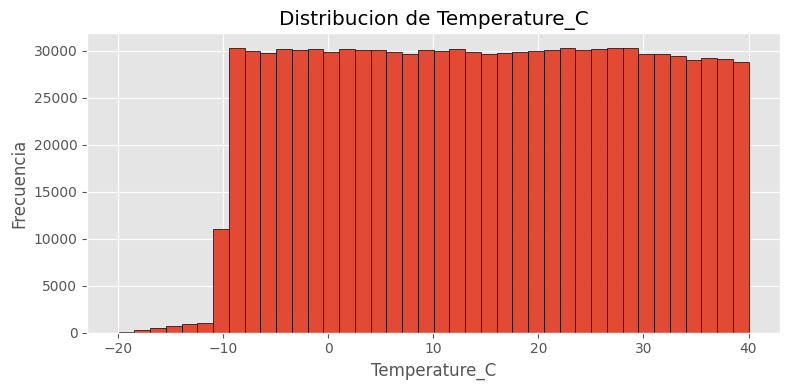

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\histograma_Temperature_C.png


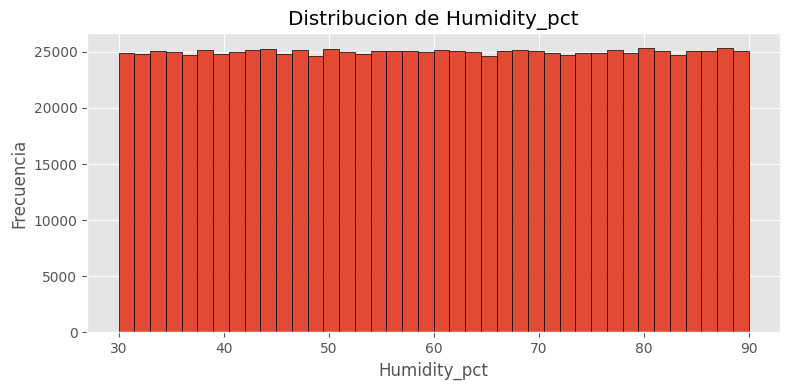

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\histograma_Humidity_pct.png


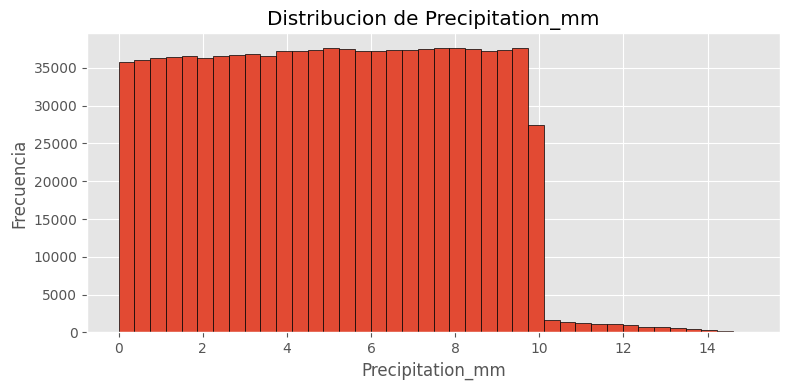

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\histograma_Precipitation_mm.png


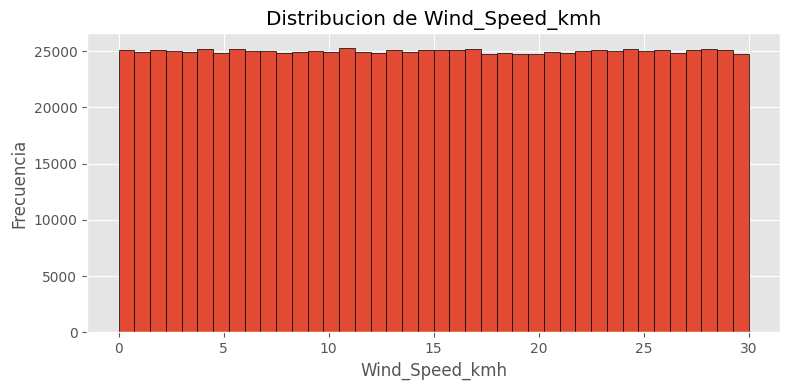

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\histograma_Wind_Speed_kmh.png


In [12]:
def guardar_figura(nombre_archivo):
    '''Guarda la figura activa en la carpeta de gráficos.'''
    ruta = FIG_DIR / nombre_archivo
    plt.tight_layout()
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grafico guardado en: {ruta}")


def graficar_histogramas(df, columnas):
    '''Genera histogramas para variables numéricas.'''
    for columna in columnas:
        plt.figure(figsize=(8, 4))
        if SEABORN_DISPONIBLE:
            sns.histplot(df[columna], bins=40, kde=True)
        else:
            plt.hist(df[columna], bins=40, edgecolor="black")
        plt.title(f"Distribucion de {columna}")
        plt.xlabel(columna)
        plt.ylabel("Frecuencia")
        guardar_figura(f"histograma_{columna}.png")


graficar_histogramas(df, ["Temperature_C", "Humidity_pct", "Precipitation_mm", "Wind_Speed_kmh"])

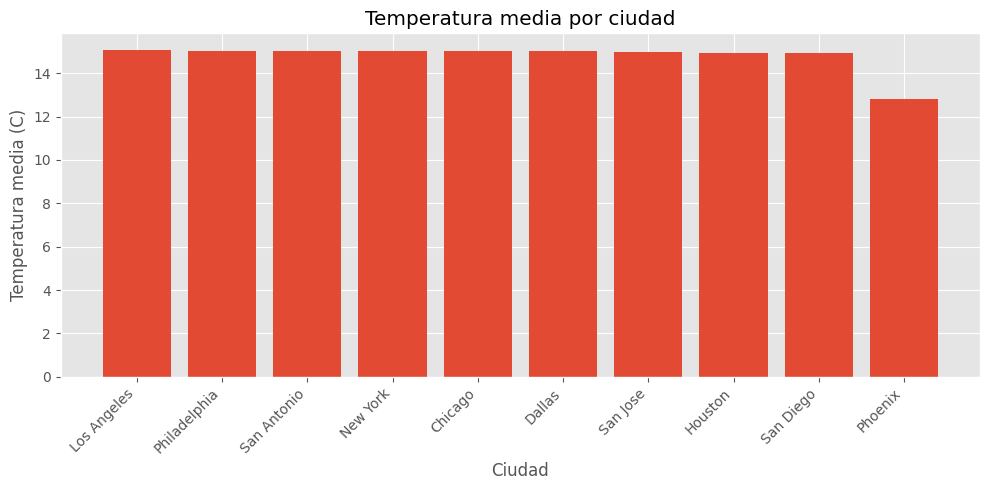

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\temperatura_media_por_ciudad.png


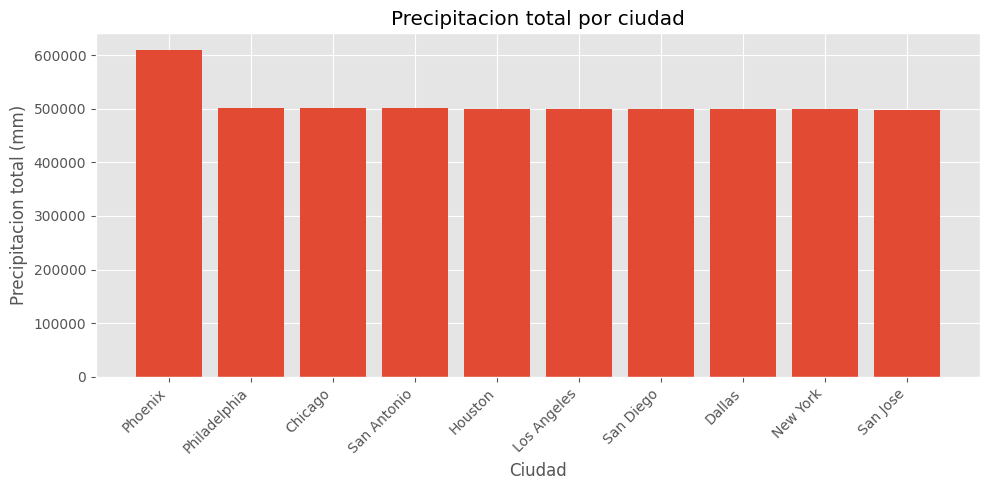

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\precipitacion_total_por_ciudad.png


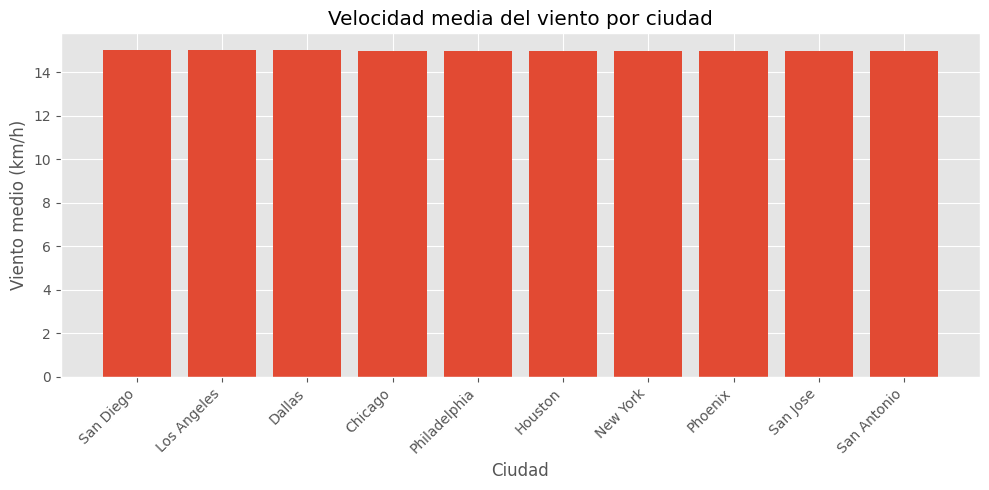

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\viento_medio_por_ciudad.png


In [13]:
def graficar_barras_ciudad(resumen_ciudad, columna, titulo, ylabel, nombre_archivo):
    '''Grafica una métrica agregada por ciudad.'''
    datos = resumen_ciudad.sort_values(columna, ascending=False)
    plt.figure(figsize=(10, 5))
    plt.bar(datos.index, datos[columna])
    plt.title(titulo)
    plt.xlabel("Ciudad")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    guardar_figura(nombre_archivo)


graficar_barras_ciudad(
    resumen_ciudad,
    "temp_media",
    "Temperatura media por ciudad",
    "Temperatura media (C)",
    "temperatura_media_por_ciudad.png"
)

graficar_barras_ciudad(
    resumen_ciudad,
    "precipitacion_total",
    "Precipitacion total por ciudad",
    "Precipitacion total (mm)",
    "precipitacion_total_por_ciudad.png"
)

graficar_barras_ciudad(
    resumen_ciudad,
    "viento_medio",
    "Velocidad media del viento por ciudad",
    "Viento medio (km/h)",
    "viento_medio_por_ciudad.png"
)

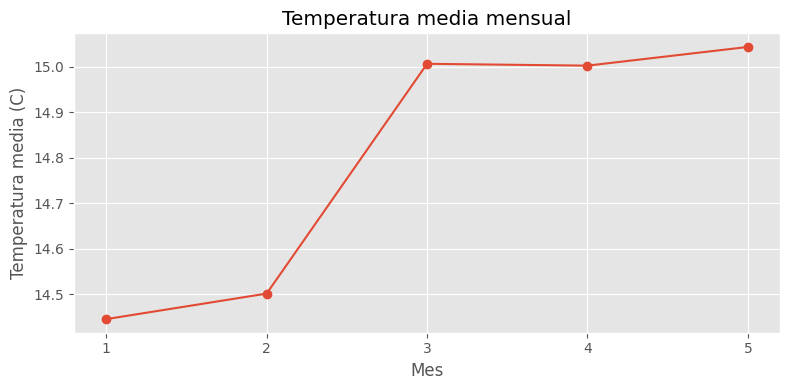

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\tendencia_temp_media_mensual.png


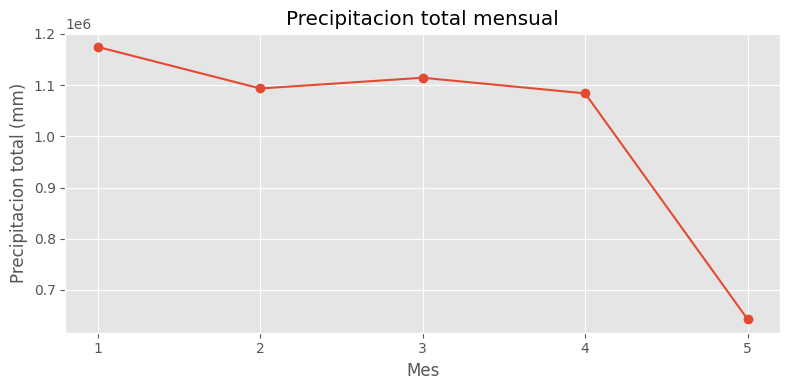

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\tendencia_precipitacion_mensual.png


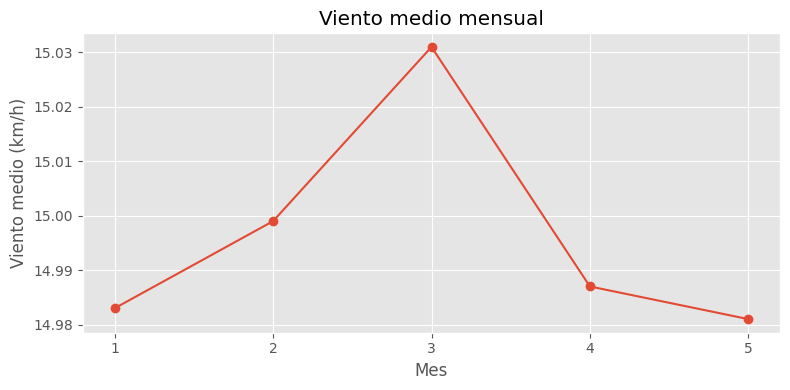

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\tendencia_viento_mensual.png


In [14]:
def graficar_tendencia_mensual(resumen_mensual):
    '''Grafica tendencias mensuales de temperatura, precipitación y viento.'''
    metricas = {
        "temp_media": ("Temperatura media mensual", "Temperatura media (C)", "tendencia_temp_media_mensual.png"),
        "precipitacion_total": ("Precipitacion total mensual", "Precipitacion total (mm)", "tendencia_precipitacion_mensual.png"),
        "viento_medio": ("Viento medio mensual", "Viento medio (km/h)", "tendencia_viento_mensual.png")
    }

    for columna, (titulo, ylabel, archivo) in metricas.items():
        plt.figure(figsize=(8, 4))
        plt.plot(resumen_mensual["Month"], resumen_mensual[columna], marker="o")
        plt.title(titulo)
        plt.xlabel("Mes")
        plt.ylabel(ylabel)
        plt.xticks(resumen_mensual["Month"])
        guardar_figura(archivo)


graficar_tendencia_mensual(resumen_mensual)

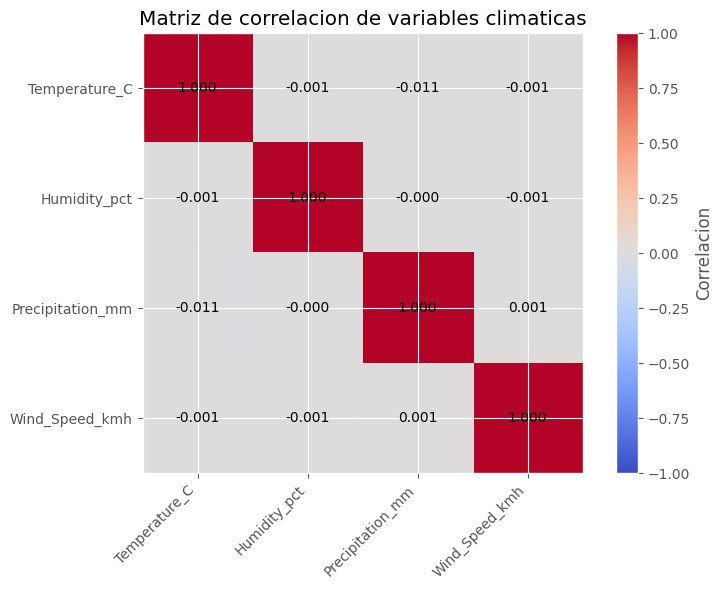

Grafico guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\graficos\matriz_correlacion.png


,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
Temperature_C,1.000,-0.001,-0.011,-0.001
Humidity_pct,-0.001,1.000,-0.000,-0.001
Precipitation_mm,-0.011,-0.000,1.000,0.001
Wind_Speed_kmh,-0.001,-0.001,0.001,1.000


In [15]:
def graficar_correlacion(df, columnas):
    '''Genera una matriz de correlación entre variables numéricas.'''
    correlacion = df[columnas].corr()
    plt.figure(figsize=(8, 6))
    if SEABORN_DISPONIBLE:
        sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1)
    else:
        plt.imshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)
        plt.colorbar(label="Correlacion")
        plt.xticks(range(len(columnas)), columnas, rotation=45, ha="right")
        plt.yticks(range(len(columnas)), columnas)
        for i in range(len(columnas)):
            for j in range(len(columnas)):
                plt.text(j, i, f"{correlacion.iloc[i, j]:.3f}", ha="center", va="center")
    plt.title("Matriz de correlacion de variables climaticas")
    guardar_figura("matriz_correlacion.png")
    return correlacion


correlacion = graficar_correlacion(df, ["Temperature_C", "Humidity_pct", "Precipitation_mm", "Wind_Speed_kmh"])
display(correlacion.round(3))

## IV.5. Filtrado y selección con Pandas

Esta sección muestra consultas útiles para responder preguntas específicas. El uso de filtros permite estudiar subconjuntos de datos, por ejemplo días cálidos, eventos con lluvia o ciudades particulares.

In [16]:
def filtrar_eventos_extremos(df):
    '''Devuelve registros con condiciones climáticas altas respecto a percentiles.'''
    umbral_temp = df["Temperature_C"].quantile(0.95)
    umbral_precip = df["Precipitation_mm"].quantile(0.95)
    umbral_viento = df["Wind_Speed_kmh"].quantile(0.95)

    extremos = df[
        (df["Temperature_C"] >= umbral_temp) |
        (df["Precipitation_mm"] >= umbral_precip) |
        (df["Wind_Speed_kmh"] >= umbral_viento)
    ].copy()

    return extremos, {
        "umbral_temp_p95": umbral_temp,
        "umbral_precip_p95": umbral_precip,
        "umbral_viento_p95": umbral_viento
    }


eventos_extremos, umbrales = filtrar_eventos_extremos(df)
print("Umbrales usados:")
for clave, valor in umbrales.items():
    print(f"{clave}: {valor:.3f}")

print("\nCantidad de eventos extremos:", len(eventos_extremos))
display(eventos_extremos.head())

Umbrales usados:
umbral_temp_p95: 37.402
umbral_precip_p95: 9.611
umbral_viento_p95: 28.496

Cantidad de eventos extremos: 143035


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Year,Month,Month_Name,Day,Hour,Thermal_Sensation_C,Temperature_Category,Rain_Event,Wind_Level
2,San Diego,2024-05-11 09:30:00,11.632436,38.820175,4.607511,28.732951,2024,5,May,11,9,3.796033,Templada,True,Alto
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,9.598282,29.898622,2024,4,April,29,13,47.486231,Muy calida,True,Alto
13,Houston,2024-05-09 00:53:00,38.641269,85.952726,0.470782,20.779264,2024,5,May,9,0,49.975520,Muy calida,True,Alto
14,Houston,2024-05-12 15:57:00,39.666772,72.747026,1.263722,6.479492,2024,5,May,12,15,51.730653,Muy calida,True,Bajo
19,San Diego,2024-01-31 05:38:00,14.605819,66.642235,1.515637,29.431890,2024,1,January,31,5,8.531622,Templada,True,Alto


In [17]:
def top_registros(df, columna, n=10):
    '''Muestra los n registros más altos para una variable.'''
    return df.sort_values(columna, ascending=False).head(n)


display(top_registros(df, "Temperature_C", 10)[["Location", "Date_Time", "Temperature_C", "Humidity_pct", "Wind_Speed_kmh"]])
display(top_registros(df, "Precipitation_mm", 10)[["Location", "Date_Time", "Precipitation_mm", "Temperature_C"]])
display(top_registros(df, "Wind_Speed_kmh", 10)[["Location", "Date_Time", "Wind_Speed_kmh", "Temperature_C"]])

,Location,Date_Time,Temperature_C,Humidity_pct,Wind_Speed_kmh
899115,New York,2024-05-16 14:31:00,39.999801,35.418345,20.988972
130221,San Diego,2024-01-29 15:18:00,39.999692,75.630696,17.344337
394340,San Diego,2024-04-14 05:44:00,39.999670,58.520672,20.814854
45231,Philadelphia,2024-05-16 04:02:00,39.999642,32.147664,20.225895
998682,Los Angeles,2024-04-25 22:56:00,39.999592,36.665352,20.169668
528217,Philadelphia,2024-01-04 17:02:00,39.999325,42.641873,19.603266
517775,San Jose,2024-03-02 09:00:00,39.999015,45.299293,4.637233
417712,Los Angeles,2024-03-11 06:55:00,39.998997,77.309298,10.229171
161913,Philadelphia,2024-05-04 00:13:00,39.998971,50.604105,11.826108
339499,New York,2024-03-22 15:34:00,39.998938,70.280803,19.110536


,Location,Date_Time,Precipitation_mm,Temperature_C
807907,Phoenix,2024-01-02 00:58:00,14.971583,-0.125291
815735,Phoenix,2024-01-16 08:12:00,14.926332,-3.586550
100653,Phoenix,2024-01-08 21:01:00,14.917006,19.848658
643869,Phoenix,2024-01-10 19:03:00,14.912323,14.200155
371574,Phoenix,2024-02-22 08:35:00,14.896195,-0.872399
613535,Phoenix,2024-02-14 02:49:00,14.853343,7.775898
33879,Phoenix,2024-01-19 23:17:00,14.837122,19.997066
777447,Phoenix,2024-01-04 13:11:00,14.829314,26.488805
435731,Phoenix,2024-02-15 10:29:00,14.826531,-5.388968
379122,Phoenix,2024-01-24 06:50:00,14.820529,24.326390


,Location,Date_Time,Wind_Speed_kmh,Temperature_C
187787,Philadelphia,2024-01-25 14:08:00,29.999973,19.914769
92380,Dallas,2024-01-27 13:13:00,29.999971,16.428828
383707,Dallas,2024-01-19 08:09:00,29.999951,36.616670
931934,Houston,2024-01-02 16:35:00,29.999948,29.883218
504457,Dallas,2024-03-14 18:43:00,29.999938,7.919686
706453,San Jose,2024-02-21 02:53:00,29.999932,13.110206
982638,San Diego,2024-04-03 22:41:00,29.999920,20.890908
468128,Chicago,2024-03-24 18:54:00,29.999889,13.518587
840833,Chicago,2024-02-24 23:27:00,29.999852,18.338017
677811,San Antonio,2024-04-13 06:12:00,29.999800,22.811103


## IV.6. Exportación de resultados

El proyecto solicita guardar el DataFrame modificado como archivo de Excel. Para crear `.xlsx` con `pandas` se necesita `openpyxl` o `xlsxwriter`. Si esas librerías no están instaladas, el cuaderno guarda un CSV alternativo y muestra el comando necesario para instalar `openpyxl`.

In [18]:
def exportar_resultados(df, resumen_ciudad, resumen_mensual):
    '''Exporta datos limpios y resúmenes a Excel o CSV según las librerías disponibles.'''
    
    ruta_excel = OUTPUT_DIR / "Weather_Data_limpio_y_resumenes.xlsx"
    
    motor_excel = None
    
    if importlib.util.find_spec("openpyxl") is not None:
        motor_excel = "openpyxl"
    elif importlib.util.find_spec("xlsxwriter") is not None:
        motor_excel = "xlsxwriter"

    print("Iniciando exportación...")

    if motor_excel is not None:
        with pd.ExcelWriter(ruta_excel, engine=motor_excel) as writer:
            
            print("Escribiendo datos limpios...")
            
            df.to_excel(writer, sheet_name="datos_limpios", index=False)
            
            print("Datos limpios terminados.")
            
            resumen_ciudad.to_excel(writer, sheet_name="resumen_ciudad")
            
            print("Resumen ciudad terminado.")
            
            resumen_mensual.to_excel(writer, sheet_name="resumen_mensual", index=False)
            
            print("Resumen mensual terminado.")
        
        print(f"Archivo Excel guardado en: {ruta_excel}")
        
        return ruta_excel

    print("No se pudo exportar a Excel porque falta openpyxl o xlsxwriter.")
    print("Instalacion sugerida: pip install openpyxl")

    ruta_csv = OUTPUT_DIR / "Weather_Data_limpio.csv"
    ruta_ciudad = OUTPUT_DIR / "resumen_ciudad.csv"
    ruta_mensual = OUTPUT_DIR / "resumen_mensual.csv"
    df.to_csv(ruta_csv, index=False)
    resumen_ciudad.to_csv(ruta_ciudad)
    resumen_mensual.to_csv(ruta_mensual, index=False)
    print(f"CSV de datos limpios guardado en: {ruta_csv}")
    print(f"CSV de resumen por ciudad guardado en: {ruta_ciudad}")
    print(f"CSV de resumen mensual guardado en: {ruta_mensual}")
    return ruta_csv


ruta_exportada = exportar_resultados(df, resumen_ciudad, resumen_mensual)

Iniciando exportación...
No se pudo exportar a Excel porque falta openpyxl o xlsxwriter.
Instalacion sugerida: pip install openpyxl
CSV de datos limpios guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\Weather_Data_limpio.csv
CSV de resumen por ciudad guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\resumen_ciudad.csv
CSV de resumen mensual guardado en: C:\Users\USER\PycharmProjects\basesProgramacion\proyecto\salidas\resumen_mensual.csv


## V. Resultados

### Interpretación preliminar de los resultados

Con la ejecución sobre el archivo disponible se observaron estos resultados principales:

- No se identificaron valores nulos ni duplicados en el dataset original.
- La temperatura media general es aproximadamente **14.78 °C**.
- La humedad relativa media es aproximadamente **60.02 %**.
- La precipitación media por registro es aproximadamente **5.11 mm**.
- La velocidad media del viento es aproximadamente **15.00 km/h**.
- El mes con temperatura promedio más alta es **mayo**, con aproximadamente **15.04 °C**.
- Como todas las fechas pertenecen a 2024, el año con más precipitación es **2024**.
- La ciudad con mayor velocidad media del viento es **San Diego**, con aproximadamente **15.04 km/h**.

Las diferencias entre ciudades son pequeñas en la mayoría de variables, lo que sugiere que el conjunto puede haber sido generado o balanceado con distribuciones similares entre ubicaciones. Un punto llamativo es **Phoenix**, que presenta menor temperatura media y mayor precipitación total que el resto de ciudades en este archivo.

## VI. Conclusiones

- Python y Pandas permiten automatizar completamente el análisis exploratorio.
- La programación mediante funciones reduce la duplicación del código.
- La automatización facilita reproducir el análisis con nuevos conjuntos de datos.
- Las visualizaciones permiten identificar rápidamente patrones y tendencias climáticas

## VII. Recomendaciones

- Incorporar análisis predictivos mediante Machine Learning.
- Integrar nuevas variables meteorológicas.
- utomatizar la actualización periódica de la base de datos.
- Publicar los resultados mediante paneles interactivos (Dash o Streamlit).

## VIII. Referencias Bibliográficas

- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
- The pandas development team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/
- NumPy Developers. (2024). *NumPy documentation*. https://numpy.org/doc/
- Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering*, 9(3), 90-95.
- Waskom, M. L. (2021). seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.
- Proyecto Primer Parcial_BasesdeProgramación.pdf. Documento de instrucciones del proyecto, Bases de Programación, Maestría en Ciencias de la Tierra.